# Financial candle dataset analysis

This notebook generates the descriptive tables and figures used in the dataset section. All return-based calculations are performed **within individual trading sessions**; overnight changes are excluded unless explicitly stated otherwise.

In [1]:
# Inputs: none. This cell contains every import used by the notebook.
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# Resolve the repository root whether the notebook is launched from the
# repository root or from the notebooks directory.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_candle_data import (
    clean_candle_splits,
    describe_split,
    load_candle_splits,
    validate_clean_split,
)
from src.visualization.candle_plots import (
    compute_persistence_movement_summary,
    compute_sector_summary,
    compute_split_summary_table,
    plot_average_intraday_abs_return,
    plot_intraday_channel,
    plot_intraday_log_returns,
    plot_return_autocorrelation,
    plot_return_correlation_heatmap,
    plot_split_volatility_distribution,
    plot_volatility_regime_correlation_heatmaps,
    plot_return_histogram,
)

print("Project root:", PROJECT_ROOT)


Project root: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis


## Load and clean the data

Each raw session contains one observation inherited from the preceding session. The standard cleaning step removes this row, leaving the regular intraday sequence used by every subsequent calculation. The three stored files are treated as containers and are repartitioned chronologically by the project loader.

In [2]:
# Inputs:
# - DATA_DIR: directory containing train.pt, val.pt, and test.pt.
# - COMPANY_PROFILES_PATH: CSV used to map the 93 project tickers to sectors.
DATA_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/Shared drives/Vishal/data/"
    "cached_datasets/exp-1m-95s-24y/session"
)
COMPANY_PROFILES_PATH = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/"
    "company_profiles.csv"
)

if not DATA_DIR.is_dir():
    raise FileNotFoundError(DATA_DIR)
if not COMPANY_PROFILES_PATH.is_file():
    raise FileNotFoundError(COMPANY_PROFILES_PATH)

train_raw, validation_raw, test_raw = load_candle_splits(DATA_DIR)
train, validation, test = clean_candle_splits(
    train_raw,
    validation_raw,
    test_raw,
)

for split_name, split in (
    ("Train", train),
    ("Validation", validation),
    ("Test", test),
):
    describe_split(split, f"clean {split_name.lower()}")
    validate_clean_split(split)



clean train
-----------
num samples: 167
T: 390
num assets: 93
channels: ['open', 'high', 'low', 'close', 'volume', 'amount']
grain: 1min
market open: 09:30
market close: 16:00
dropped days: 1
first day: 2024-01-02 00:00:00
first x shape: (390, 93, 6)
first aux: None
Validation passed for 167 samples.

clean validation
----------------
num samples: 20
T: 390
num assets: 93
channels: ['open', 'high', 'low', 'close', 'volume', 'amount']
grain: 1min
market open: 09:30
market close: 16:00
dropped days: 0
first day: 2024-09-03 00:00:00
first x shape: (390, 93, 6)
first aux: None
Validation passed for 20 samples.

clean test
----------
num samples: 62
T: 390
num assets: 93
channels: ['open', 'high', 'low', 'close', 'volume', 'amount']
grain: 1min
market open: 09:30
market close: 16:00
dropped days: 2
first day: 2024-10-01 00:00:00
first x shape: (390, 93, 6)
first aux: None
Validation passed for 62 samples.


## Dataset dimensions and chronological partitions

For a context length $L$, maximum forecast horizon $h_{\max}$, and stride $s$, the first forecast origin is $L-1$. Valid origins satisfy

$$
o_j + h_{\max} < T, \qquad o_j=(L-1)+js,
$$

where $T$ is the number of observations in the session. Counting origins separately within each session ensures that neither the context nor any target crosses a trading-day boundary.

In [3]:
# Inputs:
# - context_length: number of observed one-minute bars in each model input.
# - stride: distance between consecutive forecast origins.
# - horizons: forecast offsets evaluated by the financial experiments.
context_length = 60
stride = 15
horizons = (1, 5, 15, 30, 60)

split_summary = compute_split_summary_table(
    train,
    validation,
    test,
    context_length=context_length,
    stride=stride,
    horizons=horizons,
)

sample_x, _, sample_day = train["samples"][0]
print("First cleaned training session:", sample_day)
print("Cleaned tensor shape [time, assets, channels]:", tuple(sample_x.shape))
display(split_summary.style.hide(axis="index"))


First cleaned training session: 2024-01-02 00:00:00
Cleaned tensor shape [time, assets, channels]: (390, 93, 6)


Split,Start date,End date,Sessions,Forecast windows
Train,2024-01-02,2024-08-30,167,3173
Validation,2024-09-03,2024-09-30,20,380
Test,2024-10-01,2024-12-31,62,1178


## Sector composition

The sector table counts only the equities present in the project asset universe. Sector labels are read from `company_profiles.csv`; unrelated rows in that file are excluded.

In [4]:
# Inputs:
# - train["asset_cols"]: ordered list of project tickers.
# - COMPANY_PROFILES_PATH: sector metadata for those tickers.
sector_summary = compute_sector_summary(
    train["asset_cols"],
    company_profiles_path=COMPANY_PROFILES_PATH,
)

display(
    sector_summary.style
    .format({"Percentage of universe": "{:.1f}%"})
    .hide(axis="index")
)


Sector,Number of equities,Percentage of universe
Basic Materials,8,8.6%
Communication Services,9,9.7%
Consumer Cyclical,9,9.7%
Consumer Defensive,10,10.8%
Energy,9,9.7%
Financial Services,9,9.7%
Healthcare,10,10.8%
Industrials,10,10.8%
Technology,10,10.8%
Utilities,9,9.7%


## Representative intraday channel values

The following cell can display any raw channel for any chosen equities and sessions. In concatenated mode, only trading minutes are shown and small gaps separate consecutive sessions. Setting `normalise=True` rebases each series to its first displayed value.

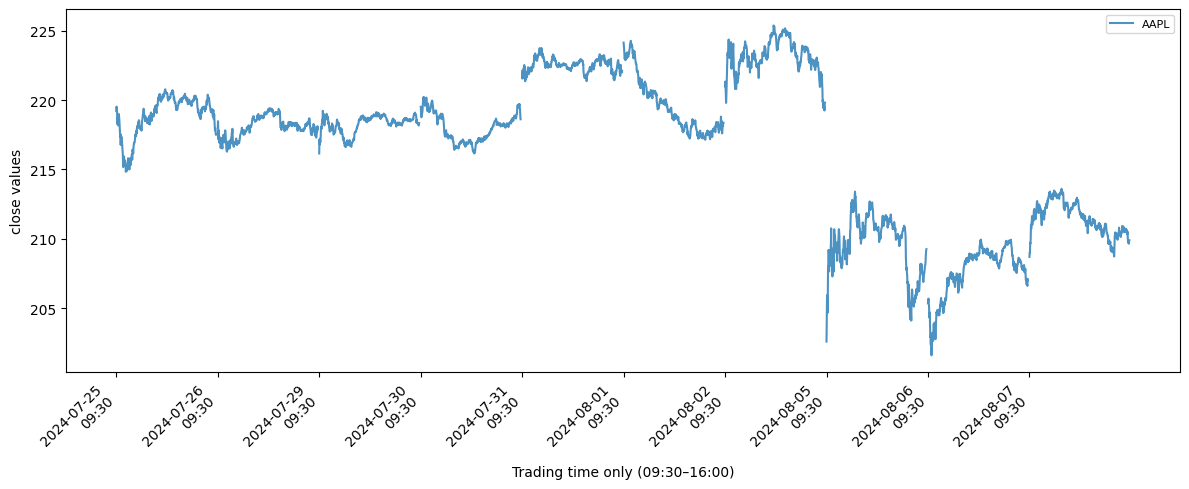

In [6]:
# Inputs:
# - selected_channel: one of open, high, low, close, volume, or amount.
# - selected_sessions: integer, list, or slice of training-session indices.
# - selected_assets: ticker names or integer asset indices.
# - show_title: set False for a clean dissertation figure.
selected_channel = "close"
selected_sessions = slice(140, 150)
selected_assets = ["AAPL"]
normalise = False
show_title = False

fig, ax = plot_intraday_channel(
    split=train,
    channel=selected_channel,
    sample_indices=selected_sessions,
    assets=selected_assets,
    normalize=normalise,
    mode="concat",
    max_samples=None,
    max_assets=None,
    title=show_title,
)
plt.show()


## Intraday log returns

For a price channel $P_{d,t,n}$, the one-minute log return is

$$
r_{d,t,n}=\log P_{d,t,n}-\log P_{d,t-1,n}.
$$

The difference is formed only when both observations belong to the same session, so the displayed series excludes overnight returns.

In [ ]:
# Inputs:
# - return_channel: price channel used to construct one-minute log returns.
# - selected_sessions and selected_assets: sessions and equities to display.
# - show_title: set False for a clean dissertation figure.
return_channel = "close"
selected_sessions = slice(140, 150)
selected_assets = ["AAPL", "AMD", "AMZN", "MSFT"]
show_title = False

fig, ax = plot_intraday_log_returns(
    split=train,
    channel=return_channel,
    sample_indices=selected_sessions,
    assets=selected_assets,
    mode="concat",
    max_samples=None,
    max_assets=None,
    title=show_title,
)
plt.show()


## Intraday volatility profile

Absolute one-minute returns provide a simple local proxy for volatility. At each bar-close time, the function computes the mean absolute return across the selected sessions and equities,

$$
\bar v_t=\frac{1}{DN}\sum_{d=1}^{D}\sum_{n=1}^{N}|r_{d,t,n}|,
$$

and shades one standard deviation across the same session--equity observations.

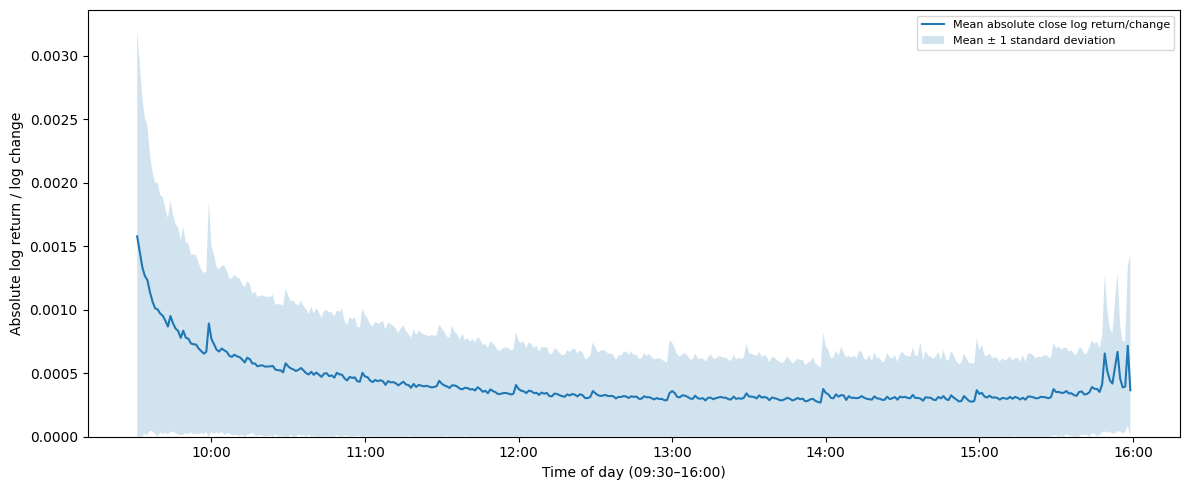

In [8]:
# Inputs:
# - profile_channel: channel whose absolute log changes are summarised.
# - sample_indices=None and assets=None: use every training session and equity.
# - show_title: set False for a clean dissertation figure.
profile_channel = "close"
show_title = False

fig, ax, average_absolute_return, absolute_return_std = (
    plot_average_intraday_abs_return(
        split=train,
        channel=profile_channel,
        sample_indices=None,
        assets=None,
        mode="profile",
        title=show_title,
    )
)
plt.show()


## Horizon-dependent movement scale

For horizon $h$, the realised cumulative log change from a forecast origin $t$ is

$$
R^{(h)}_{d,t,n}=\log C_{d,t+h,n}-\log C_{d,t,n}.
$$

A persistence forecast predicts $R^{(h)}_{d,t,n}=0$. Its cumulative-log-change MAE is therefore the mean absolute realised movement at that horizon. The table uses the same context length, stride, horizons, and within-session origin convention as the forecasting experiments.

In [9]:
# Inputs:
# - horizons, context_length, and stride: forecasting-window specification.
# - sample_indices=None and assets=None: use all training sessions and assets.
persistence_summary = compute_persistence_movement_summary(
    split=train,
    channel="close",
    sample_indices=None,
    assets=None,
    horizons=horizons,
    context_length=context_length,
    stride=stride,
)

movement_columns = [
    "persistence_raw_mae",
    "persistence_raw_rmse",
    "cumulative_log_change_std",
    "cumulative_log_change_mae",
    "median_abs_cumulative_log_change",
    "cumulative_log_change_q05",
    "cumulative_log_change_q25",
    "cumulative_log_change_q50",
    "cumulative_log_change_q75",
    "cumulative_log_change_q95",
]
display(
    persistence_summary
    .set_index("horizon")[movement_columns]
    .style.format("{:.6e}")
)


,persistence_raw_mae,persistence_raw_rmse,cumulative_log_change_std,cumulative_log_change_mae,median_abs_cumulative_log_change,cumulative_log_change_q05,cumulative_log_change_q25,cumulative_log_change_q50,cumulative_log_change_q75,cumulative_log_change_q95
horizon,,,,,,,,,,
1,9.811319e-02,2.939161e-01,5.423372e-04,3.693187e-04,2.621307e-04,-8.386475e-04,-2.635862e-04,0.000000e+00,2.603328e-04,8.104517e-04
5,2.083932e-01,5.923615e-01,1.136297e-03,7.910622e-04,5.706483e-04,-1.766182e-03,-5.802659e-04,0.000000e+00,5.599532e-04,1.672409e-03
15,3.557708e-01,1.006888e+00,1.921779e-03,1.344961e-03,9.812415e-04,-2.942178e-03,-9.561556e-04,0.000000e+00,1.002781e-03,2.857838e-03
30,4.948727e-01,1.402900e+00,2.658520e-03,1.870376e-03,1.370796e-03,-4.066008e-03,-1.328549e-03,5.029654e-05,1.411018e-03,3.957482e-03
60,6.953295e-01,1.978081e+00,3.696775e-03,2.623846e-03,1.940065e-03,-5.682868e-03,-1.857839e-03,1.054133e-04,2.014495e-03,5.561316e-03


## Return autocorrelation

For each equity and lag $k$, the function forms all valid within-session pairs

$$
\left(r_{d,t,n},\;r_{d,t+k,n}\right)
$$

across the selected sessions. The sufficient statistics of these pairs are pooled across sessions before a separate Pearson autocorrelation is calculated for each equity. No lagged pair crosses a session boundary. The solid line is the requested cross-asset mean or median of the equity-level autocorrelations; the shaded region is a cross-asset quantile band and **not** a sampling confidence interval.

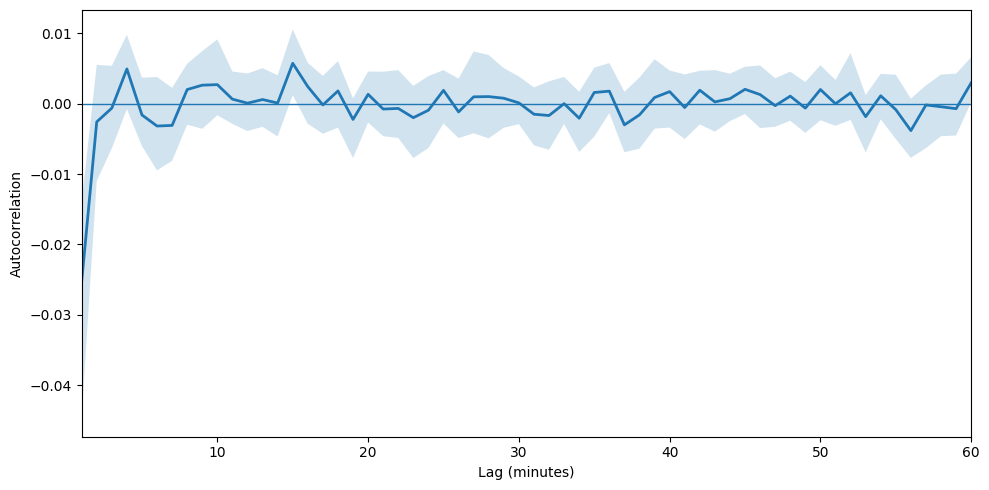

In [3]:
# Inputs:
# - max_lag and min_lag: displayed lag range in minutes.
# - centre: cross-asset mean or median ACF at each lag.
# - num_volatility_buckets=1: reproduce the original all-session ACF.
# - show_title: set False for a clean dissertation figure.
show_title = False

fig, ax, return_acf_summary = plot_return_autocorrelation(
    split=train,
    channel="close",
    sample_indices=None,
    assets=None,
    max_lag=60,
    min_lag=1,
    kind="return",
    centre="median",
    band_quantiles=(0.25, 0.75),
    num_volatility_buckets=1,
    title=show_title,
)
plt.savefig('/Users/vishalruparelia/Desktop/Thesis/Plots/acf.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Return autocorrelation by session volatility

For equity $n$ in session $d$, realised volatility is

$$
RV_{d,n}=\sqrt{\sum_t r_{d,t,n}^{2}},
$$

and the session-level market score is the cross-asset arithmetic mean

$$
V_d=\frac{1}{N}\sum_{n=1}^{N}RV_{d,n}.
$$

Sessions are ranked by $V_d$ and divided into approximately equal-sized buckets. This is an ex-post descriptive grouping used only for dataset analysis; it is not supplied to the forecasting models.

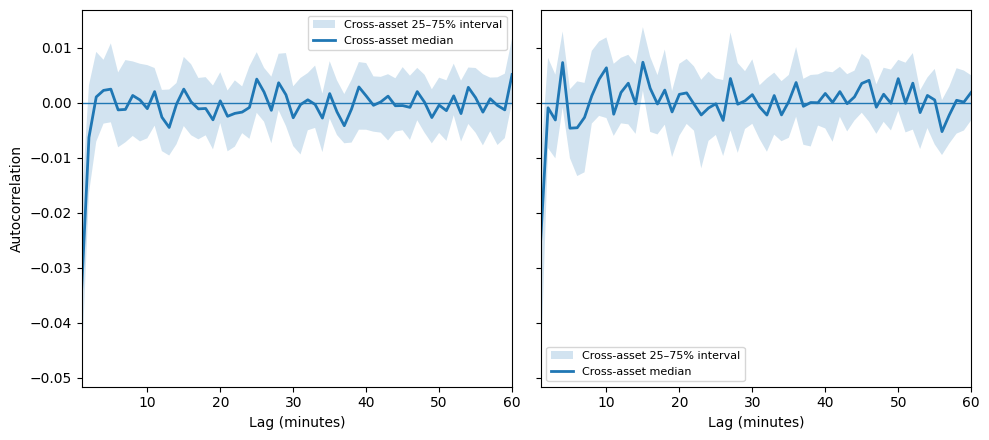

In [11]:
# Inputs:
# - num_volatility_buckets: 2 gives low/high; 3 gives low/medium/high.
# - Remaining inputs have the same meaning as the all-session ACF above.
# - show_title: set False for clean subfigures with LaTeX subcaptions.
num_volatility_buckets = 2
show_title = False

fig, axes, regime_return_acf = plot_return_autocorrelation(
    split=train,
    channel="close",
    sample_indices=None,
    assets=None,
    max_lag=60,
    min_lag=1,
    kind="return",
    centre="median",
    band_quantiles=(0.25, 0.75),
    num_volatility_buckets=num_volatility_buckets,
    title=show_title,
)
plt.show()


## Autocorrelation of return magnitude

Signed returns may exhibit little linear persistence even when the scale of movements is persistent. The next cell repeats the same within-session ACF calculation for $|r_{d,t,n}|$ and $r_{d,t,n}^{2}$. More slowly decaying autocorrelation in these transformed series is descriptive evidence of volatility clustering.

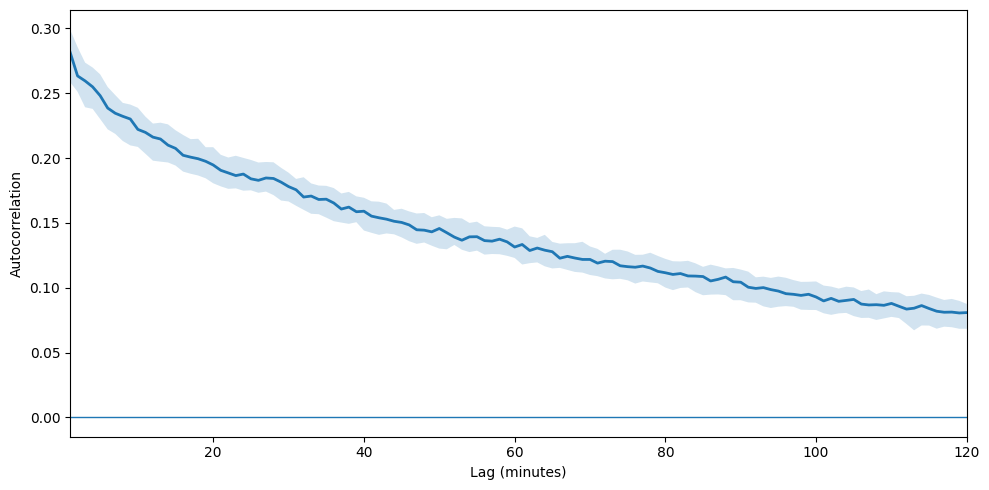

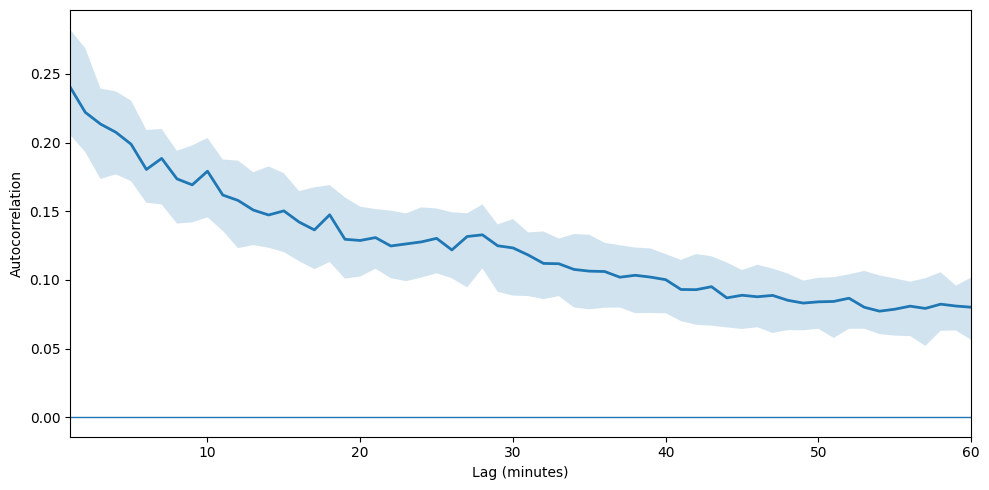

In [4]:
# Inputs:
# - magnitude_kinds: transformed return series to analyse.
# - max_lag: maximum within-session lag in minutes.
# - show_title: set False for clean dissertation figures.
magnitude_kinds = ("absolute", "squared")
max_lag_by_kind = {"absolute": 120, "squared": 60}
show_title = False

magnitude_acf_summaries = {}
for magnitude_kind in magnitude_kinds:
    fig, ax, summary = plot_return_autocorrelation(
        split=train,
        channel="close",
        sample_indices=None,
        assets=None,
        max_lag=max_lag_by_kind[magnitude_kind],
        min_lag=1,
        kind=magnitude_kind,
        centre="median",
        band_quantiles=(0.25, 0.75),
        num_volatility_buckets=1,
        title=show_title,
    )
    magnitude_acf_summaries[magnitude_kind] = summary
    plt.savefig('/Users/vishalruparelia/Desktop/Thesis/Plots/squared_acf.pdf', format='pdf', bbox_inches='tight')
    plt.show()


## Full training-set return-correlation matrix

For equities $i$ and $j$, the matrix entry is the contemporaneous Pearson correlation between their aligned one-minute close returns over the selected training sessions. With `cluster=True`, sectors and tickers are placed in a fixed alphabetical sector grouping; the correlations themselves are unchanged. The matrix describes association, not direction or causality.

Correlation matrix shape: (93, 93)


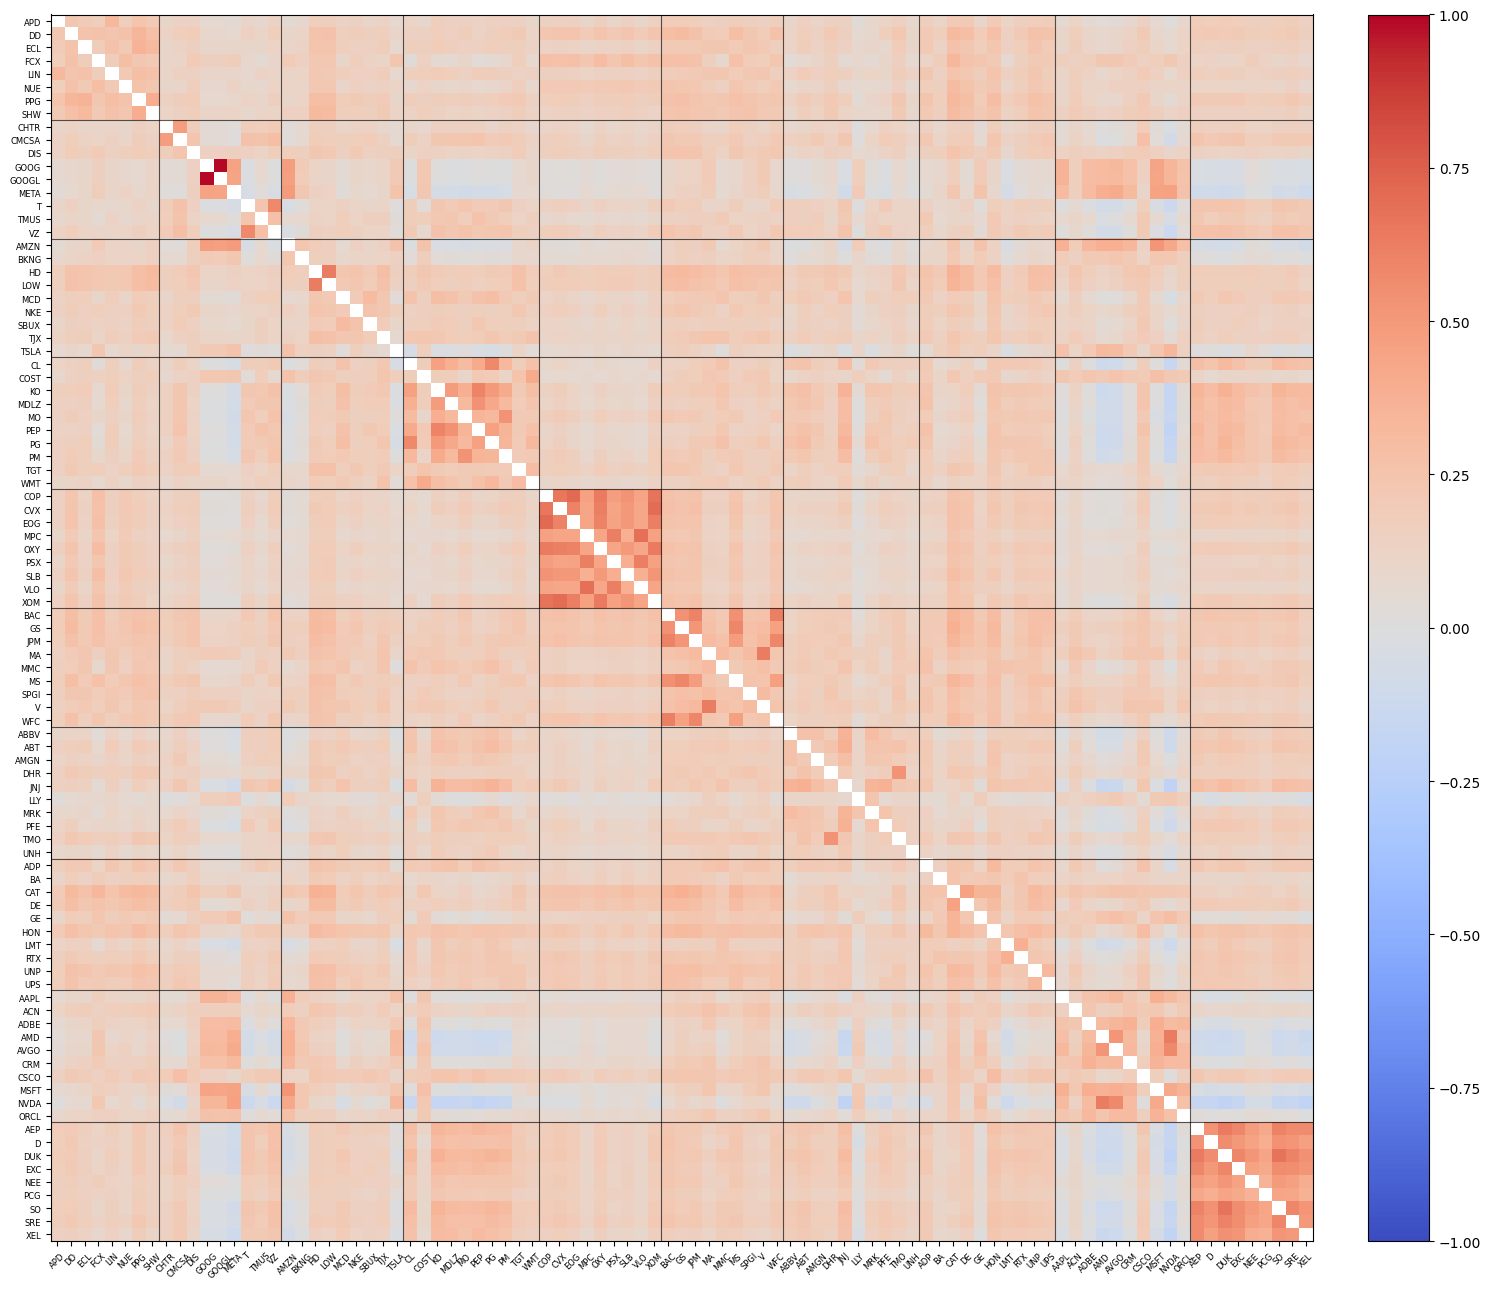

In [5]:
# Inputs:
# - cluster=True: group sectors alphabetically and tickers within each sector.
# - show_tickers: toggle all 93 ticker labels on or off.
# - show_title: set False for a clean dissertation figure.
cluster = True
show_tickers = True
show_title = False

fig, ax, training_correlation, correlation_labels = (
    plot_return_correlation_heatmap(
        split=train,
        channel="close",
        sample_indices=None,
        assets=None,
        cluster=cluster,
        company_profiles_path=COMPANY_PROFILES_PATH,
        show_tickers=show_tickers,
        title=show_title,
    )
)
print("Correlation matrix shape:", training_correlation.shape)
plt.savefig('/Users/vishalruparelia/Desktop/Thesis/Plots/heatmap.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Correlation structure by session volatility

The low- and high-volatility panels use the bottom and top fraction of training sessions ranked by $V_d$. Sessions between the two tails are excluded. Both panels use the same asset order and the same correlation scale $[-1,1]$, so colour differences represent genuine changes in correlation rather than independent rescaling.


regime
Low        16
Middle    135
High       16
Name: count, dtype: int64


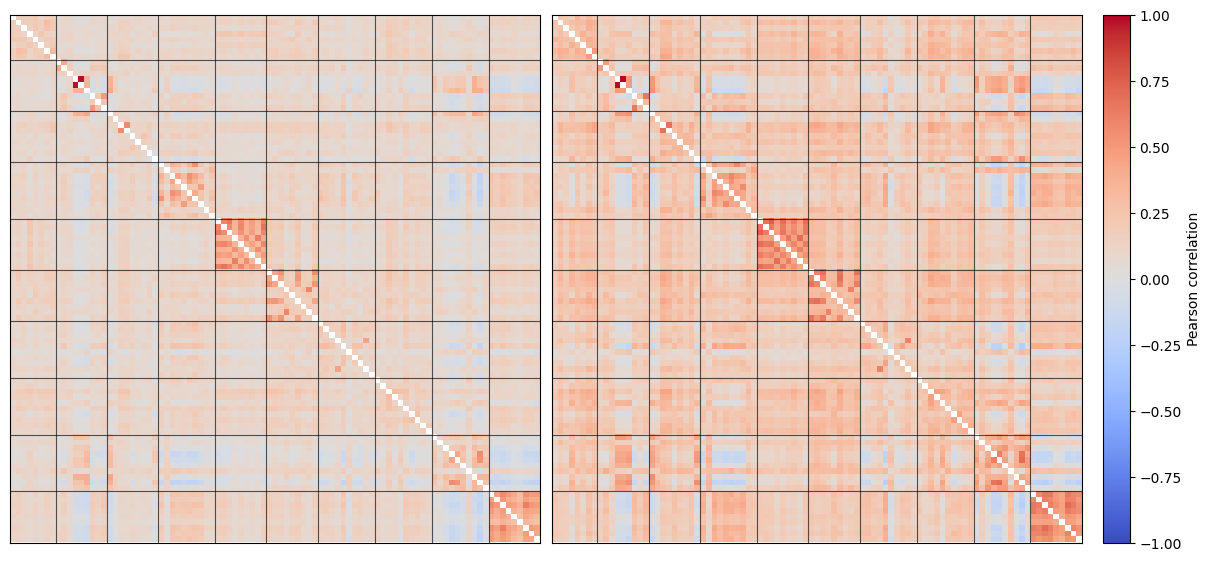

In [21]:
# Inputs:
# - volatility_tail_fraction=0.10: bottom/top 10% of training sessions.
# - cluster=True: use the same fixed sector ordering in both panels.
# - show_tickers and show_title: presentation toggles for the write-up.
volatility_tail_fraction = 0.10
cluster = True
show_tickers = False
show_title = False

(
    fig,
    axes,
    regime_correlations,
    regime_labels,
    regime_session_assignments,
) = plot_volatility_regime_correlation_heatmaps(
    split=train,
    channel="close",
    sample_indices=None,
    assets=None,
    volatility_tail_fraction=volatility_tail_fraction,
    cluster=cluster,
    company_profiles_path=COMPANY_PROFILES_PATH,
    show_tickers=show_tickers,
    title=show_title,
)

print(
    regime_session_assignments["regime"]
    .value_counts()
    .reindex(["Low", "Middle", "High"], fill_value=0)
)
plt.savefig('/Users/vishalruparelia/Desktop/Thesis/Plots/heatmap_vol.pdf', format='pdf', bbox_inches='tight')
plt.show()


## Volatility distributions across the chronological splits

The final figure applies the same session statistic $V_d$ to the training, validation, and test partitions. Comparing the distributions provides a compact diagnostic of whether the later periods exhibit materially different levels of intraday variability. The plotted quantity uses the **cross-asset mean**, not the cross-asset median.

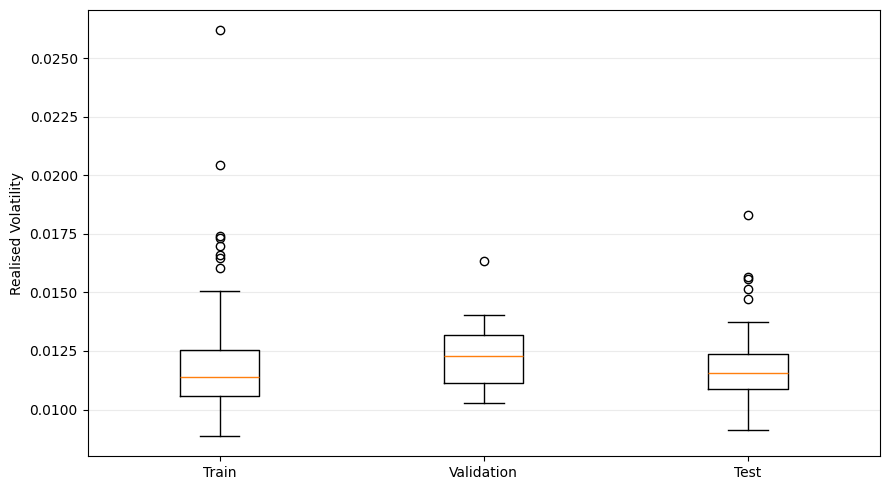

split,sessions,mean,standard_deviation,minimum,q25,median,q75,maximum
Train,167,1.183331e-02,2.110276e-03,8.867888e-03,1.058410e-02,1.138772e-02,1.256025e-02,2.620536e-02
Validation,20,1.235050e-02,1.454264e-03,1.028125e-02,1.112159e-02,1.227781e-02,1.317839e-02,1.633300e-02
Test,62,1.184401e-02,1.600092e-03,9.104768e-03,1.089695e-02,1.156103e-02,1.236946e-02,1.832058e-02


In [16]:
# Inputs:
# - train, validation, and test: cleaned chronological partitions.
# - assets=None: aggregate realised volatility across all project equities.
# - show_title: set False for a clean dissertation figure.
show_title = False

(
    fig,
    ax,
    split_session_volatility,
    split_volatility_summary,
) = plot_split_volatility_distribution(
    train,
    validation,
    test,
    channel="close",
    assets=None,
    title=show_title,
)

plt.show()
display(
    split_volatility_summary.style
    .format(
        {
            "mean": "{:.6e}",
            "standard_deviation": "{:.6e}",
            "minimum": "{:.6e}",
            "q25": "{:.6e}",
            "median": "{:.6e}",
            "q75": "{:.6e}",
            "maximum": "{:.6e}",
        }
    )
    .hide(axis="index")
)


In [3]:
# Inputs:
# - split=train uses the complete training split.
# - sample_indices=None includes every training day.
# - assets=None includes all 93 stocks.
# - channel="close" calculates within-session one-minute Close log returns.
#
# The histogram figure is closed because only the summary statistics are
# required for the dissertation.

fig, ax, pooled_training_returns, return_summary = plot_return_histogram(
    split=train,
    channel="close",
    sample_indices=None,
    assets=None,
    bins=100,
    scale_to_basis_points=True,
    show_normal=False,
    log_y=False,
    title=False,
    figsize=(8, 5),
)

plt.close(fig)

display(
    return_summary.style.format(
        {
            "Value": "{:.6f}",
        }
    )
)

,Statistic,Value,Unit
0,Mean one-minute log return,0.009257,basis points
1,Excess kurtosis,30.738692,
